<a href="https://colab.research.google.com/github/Aman1477r/ML-journey/blob/main/Ml_Day_%3D7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [5]:
import pandas as pd
df_index = pd.read_csv('economic_index.csv')

In [6]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [7]:
df_index.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')
df_index.drop(columns=["year","month"],axis=1, inplace=True)

In [8]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [9]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


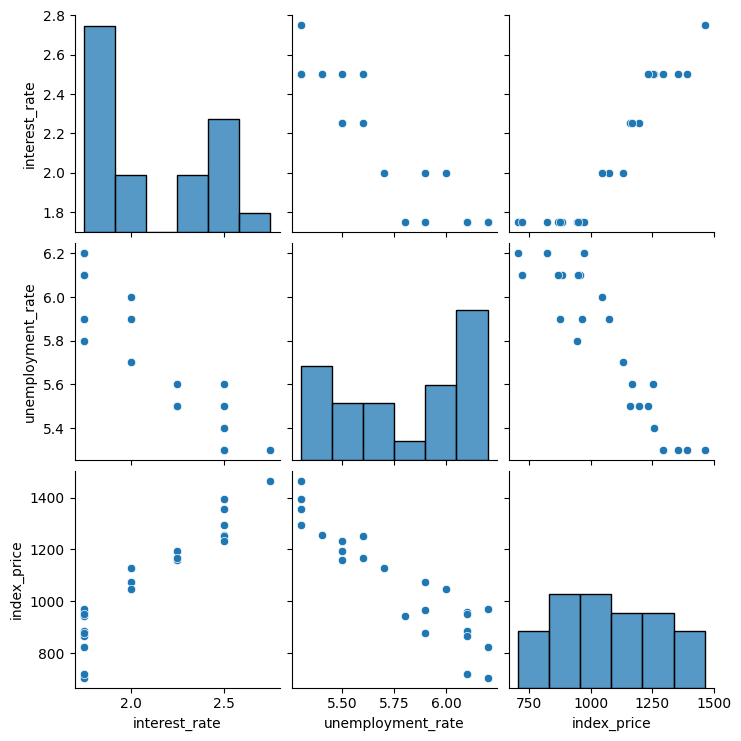

In [10]:
### LETS DO VISUALIZATION
sns.pairplot(df_index)

In [11]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


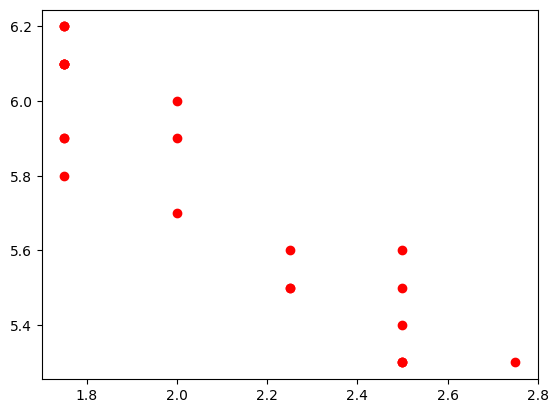

In [12]:
### visualize data set more closley
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color = 'r')

In [13]:
### independent and dependent features

X = df_index.iloc[:,:-1]
Y = df_index.iloc[:,-1]

In [14]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [15]:
Y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [16]:
## Train and test split

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=0)
#

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

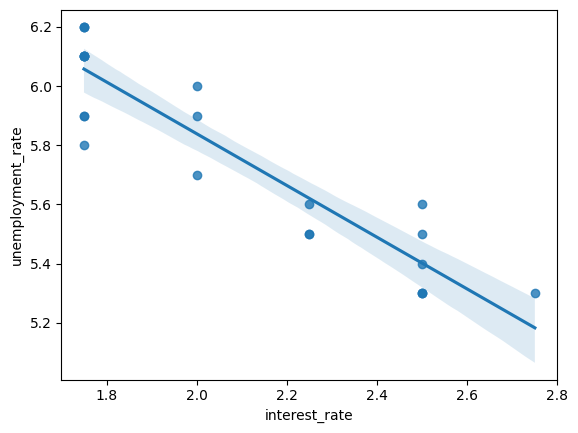

In [17]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
sc = StandardScaler()

In [20]:
X_train = sc.fit_transform(X_train)

In [21]:
X_test = sc.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lr = LinearRegression()

In [24]:
lr.fit(X_train,Y_train)

LinearRegression()

In [25]:
from sklearn.model_selection import cross_val_score

In [26]:
val = cross_val_score(lr, X_train, Y_train, cv=10)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [27]:
val

array([0.47623155, 0.85697166, 0.11867669, 0.97691131, 0.44791024,
       0.96553679,        nan,        nan,        nan,        nan])

In [28]:
np.nanmean(val)

np.float64(0.6403730382370184)

In [29]:
### Prediction
Y_pred = lr.predict(X_test)

In [30]:
Y_pred

array([1035.12987013, 1059.02797203,  898.95804196,  946.75424575,
        934.80519481, 1307.47352647,  934.80519481,  910.90709291])

In [31]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [32]:
mse = mean_squared_error(Y_test,Y_pred)
mae = mean_absolute_error(Y_test,Y_pred)
r2 = r2_score(Y_test,Y_pred)

In [33]:
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("R2 Score: ",r2)

Mean Squared Error:  11666.791077678552
Mean Absolute Error:  84.62350149850147
R2 Score:  0.7403654726255073


In [34]:
### Assumptions

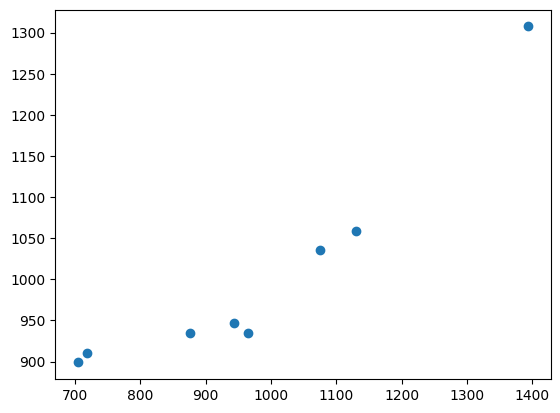

In [35]:
plt.scatter(Y_test,Y_pred)

In [36]:
resduals = Y_test - Y_pred
print(resduals)

11     39.870130
10     70.972028
22   -194.958042
14     -3.754246
20    -58.805195
1      86.526474
13     30.194805
23   -191.907093
Name: index_price, dtype: float64


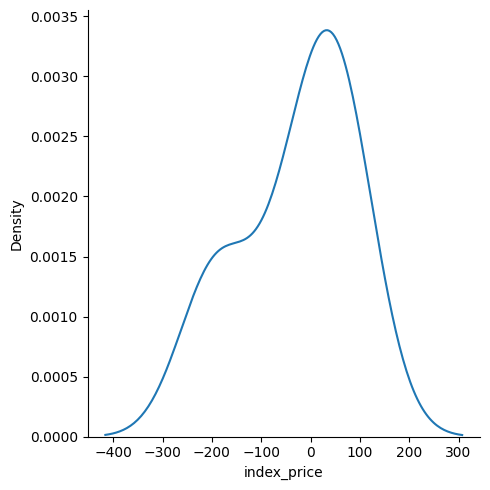

In [37]:
sns.displot(resduals,kind='kde')

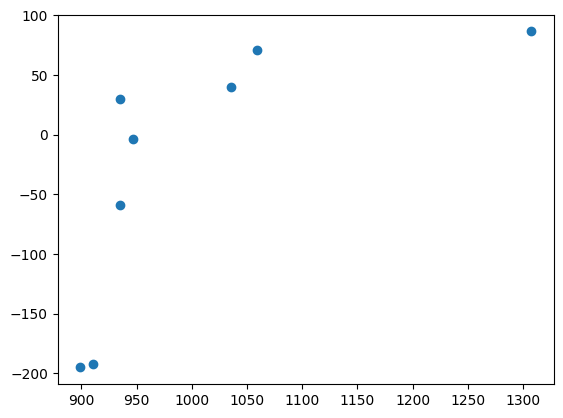

In [38]:
## scatter plot with respect to prediction and residuals

plt.scatter(Y_pred,resduals)

In [39]:
# OLS Linear regression
import statsmodels.api as sm

In [40]:
model = sm.OLS(Y_train,X_train).fit()

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.026
Model:                            OLS   Adj. R-squared (uncentered):             -0.114
Method:                 Least Squares   F-statistic:                             0.1841
Date:                Sun, 21 Jun 2026   Prob (F-statistic):                       0.834
Time:                        11:45:01   Log-Likelihood:                         -135.01
No. Observations:                  16   AIC:                                      274.0
Df Residuals:                      14   BIC:                                      275.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           141.3252   1042.171      0.136      0.894   -2093.908    2376.559
x2           -41.3658   1042.171     -0.040      0.969   -2276.599    2193.868
==============================================================================
Omnibus:                        1.430   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.489   Jarque-Bera (JB):                0.840
Skew:                           0.061   Prob(JB):                        0.657
Kurtosis:                       1.884   Cond. No.                         6.83
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""